Skills Demonstrated

✔ Data Loading using Pandas
✔ Data Exploration
✔ Feature Selection
✔ Train-Test Split
✔ Linear Regression
✔ Model Evaluation
✔ Data Visualization
✔ Model Improvement

In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [29]:
# Read the CSV file
df = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")

In [30]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [31]:
df.shape

(1460, 81)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [33]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [34]:
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']]

In [35]:
y = df['SalePrice']

In [36]:
X.head()

,GrLivArea,BedroomAbvGr,FullBath
0,1710,3,2
1,1262,3,2
2,1786,3,2
3,1717,3,1
4,2198,4,2


In [37]:
y.head()

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
print(X_train.shape)
print(X_test.shape)

(1168, 3)
(292, 3)


In [40]:
model = LinearRegression()

In [41]:
model.fit(X_train, y_train)

LinearRegression()

In [42]:
predictions = model.predict(X_test)

In [43]:
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 35788.061292436294


In [44]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)
rmse = mean_squared_error(y_test, predictions) ** 0.5
print("RMSE:", rmse)

MSE: 2806426667.247853
RMSE: 52975.71771338122


In [45]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)

print("R2 Score:", r2)

R2 Score: 0.6341189942328371


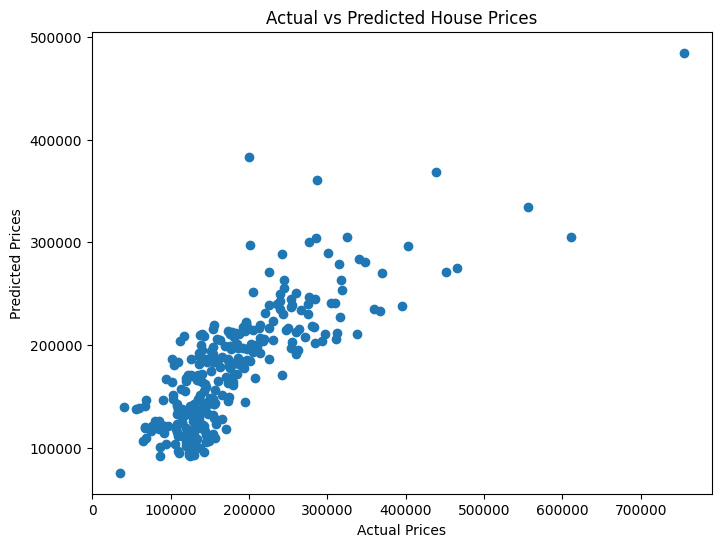

In [46]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [47]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": predictions
})

comparison.head(10)

,Actual Price,Predicted Price
892,154500,113410.672553
1105,325000,305081.877759
413,115000,135904.785630
522,159000,205424.675641
1036,315500,227502.683490
614,75500,121157.480796
218,311500,205577.980566
1160,146000,183787.203783
649,84500,121157.480796
887,135500,147219.222332


# Experiment: Adding More Features

In [48]:
X = df[
    [
        'GrLivArea',
        'BedroomAbvGr',
        'FullBath',
        'OverallQual',
        'GarageArea',
        'GarageCars',
        'YearBuilt'
    ]
]

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [50]:
print(X_train.shape)
print(X_test.shape)

(1168, 7)
(292, 7)


In [51]:
model = LinearRegression()

In [52]:
model.fit(X_train, y_train)

LinearRegression()

In [53]:
predictions = model.predict(X_test)

In [54]:
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 26944.877297916697


In [55]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
print("MSE:", mse)
rmse = mean_squared_error(y_test, predictions) ** 0.5
print("RMSE:", rmse)

MSE: 1689348093.3991208
RMSE: 41101.67993402606


In [56]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)

print("R2 Score:", r2)

R2 Score: 0.7797553783545483


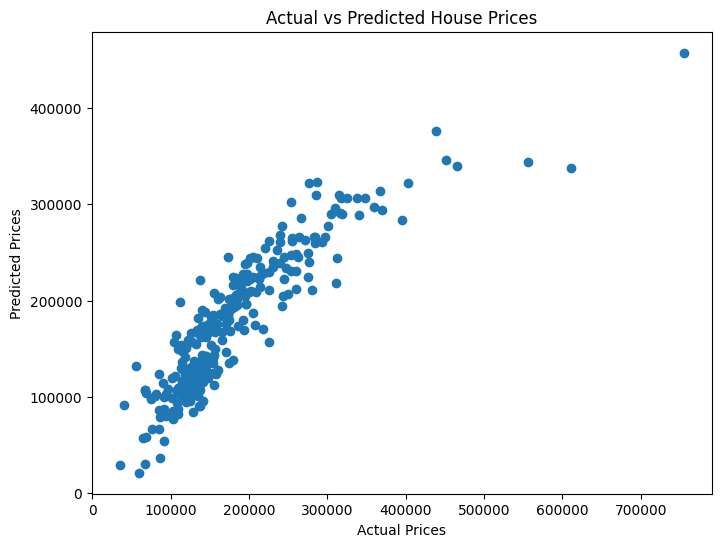

In [57]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [58]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": predictions
})

comparison.head(10)

,Actual Price,Predicted Price
892,154500,135181.381005
1105,325000,306336.066573
413,115000,116822.566055
522,159000,175333.644301
1036,315500,290856.308367
614,75500,67018.630234
218,311500,217912.252974
1160,146000,175005.824614
649,84500,66208.415177
887,135500,132717.595271


In [59]:
results = pd.DataFrame({
    "Model": ["Baseline", "Improved"],
    "Features": [3, 8],
    "R2 Score": [0.6341, 0.7797553783545483]
})

results

,Model,Features,R2 Score
0,Baseline,3,0.634100
1,Improved,8,0.779755


Residuals

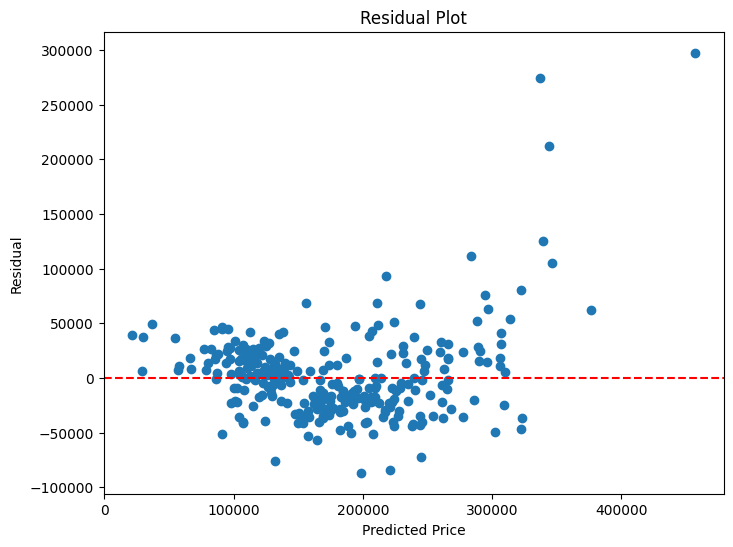

In [60]:
residuals = y_test - predictions

plt.figure(figsize=(8,6))

plt.scatter(predictions, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

FEATURE IMPORTANCE

In [61]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,GrLivArea,64.529165
1,BedroomAbvGr,-7747.197607
2,FullBath,-5651.711000
3,OverallQual,21159.547844
4,GarageArea,26.795661
5,GarageCars,9646.189489
6,YearBuilt,405.107528


plotting coefficients

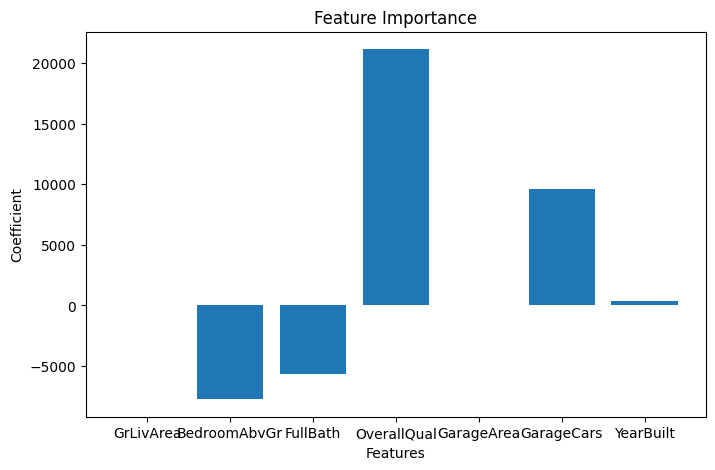

In [62]:
plt.figure(figsize=(8,5))

plt.bar(coefficients["Feature"], coefficients["Coefficient"])

plt.title("Feature Importance")

plt.xlabel("Features")
plt.ylabel("Coefficient")

plt.show()

Conclusion

This project implemented a Linear Regression model to predict house prices using living area, bedrooms, and bathrooms.

The baseline model achieved an R² score of approximately 0.63. To improve performance, additional relevant features such as OverallQual, GarageArea, GarageCars, YearBuilt, and TotalBsmtSF were included. This increased the R² score to approximately 0.77, demonstrating that incorporating more meaningful features can significantly improve prediction accuracy.

The project also evaluated the model using MAE, MSE, RMSE, and R² Score, and visualized predictions through scatter plots and residual analysis.